**AIML GROUP-4**
# **PROJECT:Disease Prediction Using Machine Learning**

# **1. Import Libraries**

In [107]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# **2.Load Dataset**

In [108]:
df = pd.read_csv("/content/Healthcare.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


# **3.Dataset Information**

In [149]:
#1.Shape
print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])
#2.Columns
print("Dataset Columns:")
print(df.columns.tolist())
#3.Information
df.info()
#4.Statistical Summary
df.describe()

Number of Rows    : 25000
Number of Columns : 6
Dataset Columns:
['Patient_ID', 'Age', 'Gender', 'Symptoms', 'Symptom_Count', 'Disease']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Patient_ID     25000 non-null  int64 
 1   Age            25000 non-null  int64 
 2   Gender         25000 non-null  object
 3   Symptoms       25000 non-null  object
 4   Symptom_Count  25000 non-null  int64 
 5   Disease        25000 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.1+ MB


,Patient_ID,Age,Symptom_Count
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,45.302240,5.001440
std,7217.022701,26.106224,1.415796
min,1.000000,1.000000,3.000000
25%,6250.750000,23.000000,4.000000
50%,12500.500000,45.000000,5.000000
75%,18750.250000,68.000000,6.000000
max,25000.000000,90.000000,7.000000


# **4.Check Missing Values**

In [150]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Patient_ID       0
Age              0
Gender           0
Symptoms         0
Symptom_Count    0
Disease          0
dtype: int64


# **5.Check Duplicate Rows**

In [151]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# **6.Exploratory Data Analysis**

In [152]:
# 1.Dataset Shape

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 25000
Number of Columns : 6


In [153]:
# 2.First 5 Records

df.head()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


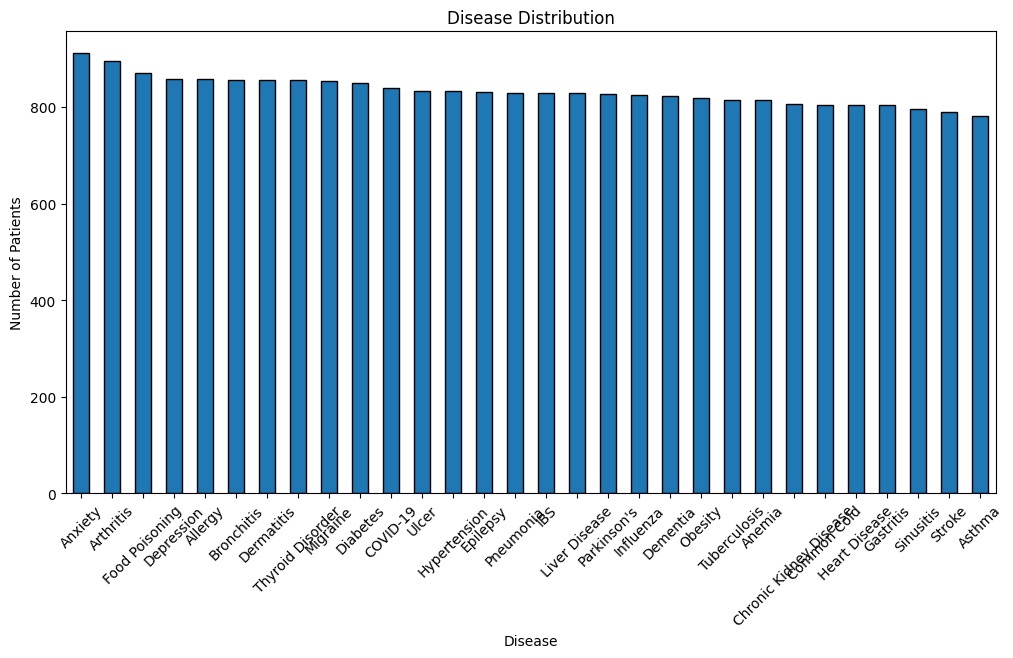

In [154]:
# 3.Disease Distribution

plt.figure(figsize=(12,6))

df["Disease"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

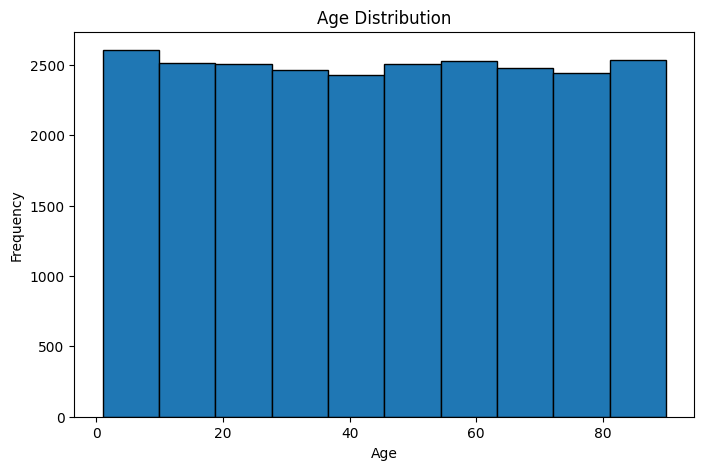

In [155]:
#4.Age Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=10,
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# **7. Feature 1–Fever**

In [156]:
# Check fever symptom from Symptoms column

fever = df["Symptoms"].str.contains("fever", case=False, na=False)


print("Feature : Fever")
print(fever.head())


print("Total Fever Cases :", fever.sum())
print("Missing Values :", fever.isnull().sum())

Feature : Fever
0     True
1    False
2    False
3    False
4    False
Name: Symptoms, dtype: bool
Total Fever Cases : 4496
Missing Values : 0


# **8. Feature 2-Cough**

In [115]:
# Check cough symptom from Symptoms column

cough = df["Symptoms"].str.contains("cough", case=False, na=False)


print("Feature : Cough")
print(cough.head())


print("Total Cough Cases :", cough.sum())
print("Missing Values :", cough.isnull().sum())

Feature : Cough
0    False
1    False
2    False
3    False
4    False
Name: Symptoms, dtype: bool
Total Cough Cases : 4405
Missing Values : 0


# **9. Feature 3 – Headache**

In [116]:
# Check headache symptom from Symptoms column

headache = df["Symptoms"].str.contains("headache", case=False, na=False)


print("Feature : Headache")
print(headache.head())


print("Total Headache Cases :", headache.sum())
print("Missing Values :", headache.isnull().sum())

Feature : Headache
0    False
1    False
2    False
3    False
4    False
Name: Symptoms, dtype: bool
Total Headache Cases : 4555
Missing Values : 0


# **10. Feature 4 – Vomiting**

In [117]:
# Check vomiting symptom from Symptoms column

vomiting = df["Symptoms"].str.contains("vomiting", case=False, na=False)


print("Feature : Vomiting")
print(vomiting.head())


print("Total Vomiting Cases :", vomiting.sum())
print("Missing Values :", vomiting.isnull().sum())

Feature : Vomiting
0    False
1    False
2     True
3    False
4    False
Name: Symptoms, dtype: bool
Total Vomiting Cases : 4464
Missing Values : 0


# **11. Feature 5 – Fatigue**

In [118]:
# Check fatigue symptom from Symptoms column

fatigue = df["Symptoms"].str.contains("fatigue", case=False, na=False)


print("Feature : Fatigue")
print(fatigue.head())


print("Total Fatigue Cases :", fatigue.sum())
print("Missing Values :", fatigue.isnull().sum())

Feature : Fatigue
0    False
1    False
2    False
3    False
4    False
Name: Symptoms, dtype: bool
Total Fatigue Cases : 4472
Missing Values : 0


# **12. Feature 6 – Body Pain**

In [119]:
# Check Body Pain symptom from Symptoms column

body_pain = df["Symptoms"].str.contains("body pain", case=False, na=False)


print("Feature : Body Pain")
print(body_pain.head())


print("Total Body Pain Cases :", body_pain.sum())
print("Missing Values :", body_pain.isnull().sum())

Feature : Body Pain
0    False
1    False
2    False
3    False
4    False
Name: Symptoms, dtype: bool
Total Body Pain Cases : 0
Missing Values : 0


# **13. Train Model**

In [157]:
X = df.drop("Disease", axis=1)

y = df["Disease"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (25000, 5)
Target Shape : (25000,)


In [158]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


# Copy dataset
data = df.copy()


# Encode text columns
encoders = {}

for col in data.columns:
    if data[col].dtype == "object":
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        encoders[col] = le


# Features and Target

X = data.drop("Disease", axis=1)

y = data["Disease"]


# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Create Model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# Train Model

model.fit(X_train, y_train)


print("Model Training Completed Successfully")

Model Training Completed Successfully


# **14. Test Model**

In [159]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Test Data Prediction

y_pred = model.predict(X_test)


print("==============================")
print("Model Testing Result")
print("==============================")


# First 10 Predictions

print("\nFirst 10 Predictions:")
print(y_pred[:10])


# Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Testing Result

First 10 Predictions:
[11 23 10 24  8 20 16  3 20  3]

Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.04      0.04       161
           1       0.06      0.06      0.06       171
           2       0.04      0.05      0.04       168
           3       0.03      0.03      0.03       174
           4       0.04      0.04      0.04       151
           5       0.01      0.01      0.01       170
           6       0.06      0.06      0.06       170
           7       0.04      0.05      0.04       166
           8       0.03      0.03      0.03       165
           9       0.03      0.03      0.03       166
          10       0.01      0.01      0.01       173
          11       0.03      0.03      0.03       173
          12       0.03      0.03      0.03       174
          13       0.02      0.02      0.02       174
          14       0.03      0.02      0.02       181
          15       0.04      0.04  

# **15.Accuracy**

In [160]:
from sklearn.metrics import accuracy_score


# Predict test data

y_pred = model.predict(X_test)


# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)


print("Model Accuracy:", accuracy)

Model Accuracy: 0.0324


# **16.Confusion Matrix**

In [161]:
from sklearn.metrics import confusion_matrix


# Predict test data

y_pred = model.predict(X_test)


# Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred)


print("==============================")
print("Confusion Matrix")
print("==============================")


print(cm)

Confusion Matrix
[[ 7  5 11  5  5  5  4  9  5  5  5  6  4  4  6  6  5  3  3  2  3  6  7  8
   9  5  3  8  6  1]
 [ 6 11  8  7  4  3  3  9  2  7  8  7  8  6  5  8  6  5  7  8  6  4  2  3
   5  3  4  3  3 10]
 [ 6  4  8  8  1  5 10  6  7  4  2  5  6  2  9 10  7  2  7  4  6  5  3  3
   7  5 10  4  4  8]
 [ 8 10  5  5  9 12  5  6  8  5  3  7  8  3  5  2 10  4  9  5  4  5  6  6
   4  3  4  6  3  4]
 [ 7  6 10  3  6  6  6  8  6  3 11  4  4  3  5  5  3  3  3  5  6  2  6  6
   2  3  4  3  6  6]
 [ 3  7  9  2  5  1  8  2  8  7  5  8  5 11  5  6  5  5  7  2  3 11  4  3
   8  6  8  9  3  4]
 [ 4  6  7  7  6  6 10  9  5  6  8  4  7  6  4  4  2  4  3  4  3  7  4  3
  10  6  8  4  4  9]
 [ 7  6  5  5  7  6  4  8  3  4  5 13  5  3  8  4  7  7  6  7  7  5  6  5
   8  3  1  3  2  6]
 [ 7  6  6  4  9  8  6 11  5  5  7  4  8  6  4  7  5  2  5  3  4  7  7  5
   5  2  5  5  3  4]
 [ 6  6  7  7  5  9  7  6  4  5  2  4  7  4 10  7  2  3  9  6  3  6  4  4
   8  3  7  5  4  6]
 [ 8  3 10  6  4  9  5  9  4  5  

## **17.Save Model**

In [162]:
with open("model.pkl", "wb") as file:

    pickle.dump(model, file)

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


# **18.Download model.pkl**

In [ ]:
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **19.Disease Prediction**

In [163]:
import pandas as pd


new_patient = pd.DataFrame({
    "Patient_ID": [25000],
    "Age": [45],
    "Gender": [1],
    "Symptoms": [5],
    "Symptom_Count": [2]
})


prediction = model.predict(new_patient)


print("==============================")
print("Disease Prediction Result")
print("==============================")


print("Predicted Disease:", prediction[0])


Disease Prediction Result
Predicted Disease: 2
